First 5 rows:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  


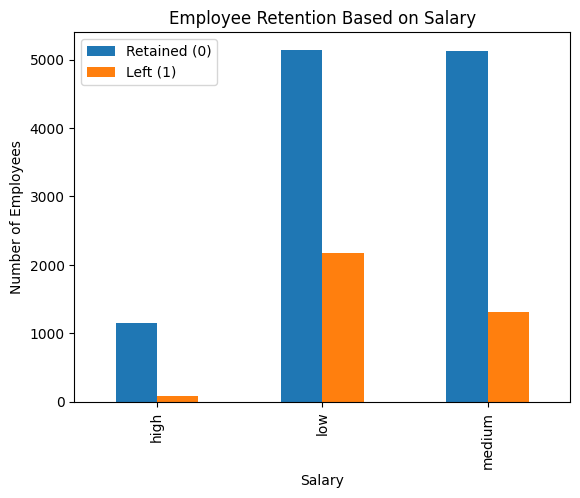

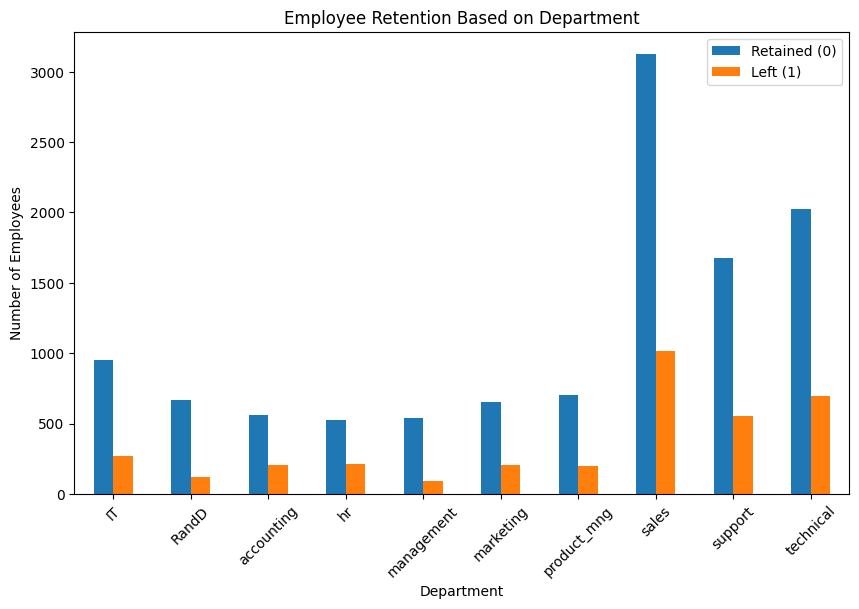


Model Accuracy: 0.7675555555555555

Confusion Matrix:
[[3196  232]
 [ 814  258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      3428
           1       0.53      0.24      0.33      1072

    accuracy                           0.77      4500
   macro avg       0.66      0.59      0.59      4500
weighted avg       0.73      0.77      0.73      4500



In [2]:
# -----------------------------
# Import Required Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("HR_comma_sep.csv")

# -----------------------------
# 1. Exploratory Data Analysis
# -----------------------------
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nCheck Missing Values:")
print(df.isnull().sum())

print("\nEmployee Retention Count:")
print(df['left'].value_counts())

print("\nAverage values grouped by 'left':")
print(df.groupby('left').mean(numeric_only=True))

# -----------------------------
# 2. Bar Chart: Salary vs Retention
# -----------------------------
salary_retention = pd.crosstab(df['salary'], df['left'])
salary_retention.plot(kind='bar')
plt.title("Employee Retention Based on Salary")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.legend(["Retained (0)", "Left (1)"])
plt.show()

# -----------------------------
# 3. Bar Chart: Department vs Retention
# -----------------------------
dept_retention = pd.crosstab(df['Department'], df['left'])
dept_retention.plot(kind='bar', figsize=(10,6))
plt.title("Employee Retention Based on Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.legend(["Retained (0)", "Left (1)"])
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 4. Feature Selection (Based on EDA)
# -----------------------------
X = df[['satisfaction_level',
        'average_montly_hours',
        'promotion_last_5years',
        'salary']]

# Convert categorical salary column into dummy variables
X = pd.get_dummies(X, columns=['salary'], drop_first=True)

y = df['left']

# -----------------------------
# 5. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 6. Build Logistic Regression Model
# -----------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# -----------------------------
# 7. Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 8. Model Evaluation
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

First 5 rows:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2     

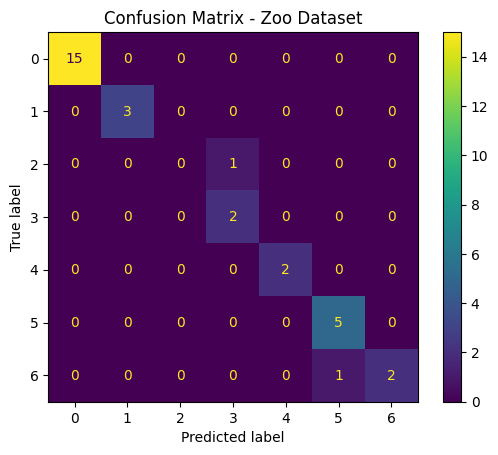

In [5]:
# ---------------------------------
# Import Libraries
# ---------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------
# 1. Load Dataset Properly
# ---------------------------------

# Load with header row
df = pd.read_csv("zoo-data.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# ---------------------------------
# 2. Data Preprocessing
# ---------------------------------

# Drop animal_name (not useful for prediction)
df = df.drop("animal_name", axis=1)

# Convert all columns to numeric (important fix)
df = df.apply(pd.to_numeric)

# Separate features and target
X = df.drop("class_type", axis=1)
y = df["class_type"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------------------------
# 3. Build Logistic Regression Model
# ---------------------------------

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# ---------------------------------
# 4. Measure Accuracy
# ---------------------------------

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# ---------------------------------
# 5. Confusion Matrix
# ---------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Zoo Dataset")
plt.show()